<a href="https://colab.research.google.com/github/Katsuraya3215/AI-study/blob/main/colab/7/7-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
##================================================
## このセルを最初に実行せよ---Run this cell first.
##================================================
!wget -P . https://raw.githubusercontent.com/utokyo-ipp/utokyo-ipp.github.io/master/colab/7/iris.csv

--2026-03-16 12:48:49--  https://raw.githubusercontent.com/utokyo-ipp/utokyo-ipp.github.io/master/colab/7/iris.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3716 (3.6K) [text/plain]
Saving to: ‘./iris.csv’

iris.csv            100%[===================>]   3.63K  --.-KB/s    in 0s      

2026-03-16 12:48:49 (39.2 MB/s) - ‘./iris.csv’ saved [3716/3716]



# 7-2. scikit-learnライブラリ

scikit-learnライブラリについて説明します。

参考

- https://scikit-learn.org/stable/tutorial/index.html
- https://scikit-learn.org/stable/getting_started.html

機械学習の各手法の詳細については以下を参考にしてください

- https://elf-c.he.u-tokyo.ac.jp/courses/364 （線形回帰）
- https://elf-c.he.u-tokyo.ac.jp/courses/365 （ロジスティック回帰)
- https://elf-c.he.u-tokyo.ac.jp/courses/360 （クラスタリング）
- https://elf-c.he.u-tokyo.ac.jp/courses/363 （次元削減（主成分分析））

**scikit-learn**ライブラリには分類、回帰、クラスタリング、次元削減、前処理、モデル選択などの機械学習の処理を行うためのモジュールが含まれています。以下では、scikit-learnライブラリのモジュールの基本的な使い方について説明します。

## 機械学習について
**機械学習**では、観察されたデータをよく表すようにモデルのパラメータの調整を行います。パラメータを調整することでモデルをデータに適合させるので、「学習」と呼ばれます。学習されたモデルを使って、新たに観測されたデータに対して予測を行うことが可能になります。

## 教師あり学習
機械学習において、観測されたデータの特徴（特徴量）に対して、そのデータに関するラベルが存在する時、**教師あり学習**と呼びます。教師あり学習では、ラベルを教師として、データからそのラベルを予測するようなモデルを学習することになります。この時、ラベルが連続値であれば回帰、ラベルが離散値であれば分類の問題となります。

## 教師なし学習
ラベルが存在せず、観測されたデータの特徴のみからそのデータセットの構造やパターンをよく表すようなモデルを学習することを**教師なし学習**と呼びます。クラスタリングや次元削減は教師なし学習です。クラスタリングでは、観測されたデータをクラスタと呼ばれる集合にグループ分けします。次元削減では、データの特徴をより簡潔に（低い次元で）表現します。

## データ
機械学習に用いるデータセットは、データフレームあるいは2次元の配列として表すことができます。行はデータセットの個々のデータを表し、列はデータが持つ特徴を表します。以下では、例として `pandas` モジュールの説明で用いたアイリスデータセットを表示しています。

In [2]:
import pandas as pd
iris = pd.read_csv('iris.csv')
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


データセットの各行は1つの花のデータに対応しており、行数はデータセットの花データの総数を表します。また、1列目から4列目までの各列は花の特徴（特徴量）に対応しています。scikit-learnでは、このデータと**特徴量**からなる2次元配列（行列）をNumPy配列または `pandas` のデータフレームに格納し、入力データとして処理します。5列目は、教師あり学習におけるデータのラベルに対応しており、ここでは各花データの花の種類（全部で3種類）を表しています。ラベルは通常1次元でデータの数だけの長さを持ち、NumPy配列または `pandas` のシリーズに格納します。先に述べた通り、ラベルが連続値であれば回帰、ラベルが離散値であれば分類の問題となります。機械学習では、特徴量からこのラベルを予測することになります。

アイリスデータセットはscikit-learnが持つデータセットにも含まれており、`load_iris` 関数によりアイリスデータセットの特徴量データとラベルデータを以下のようにNumPyの配列として取得することもできます。この時、ラベルは数値 (`0`, `1`, `2`) に置き換えられています。

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

## モデル学習の基礎

scikit-learnでは、以下の手順でデータからモデルの学習を行います。

- 使用するモデルのクラスの選択
- モデルのハイパーパラメータの選択とインスタンス化
- データの準備
    - 教師あり学習では、特徴量データとラベルデータを準備
    - 教師あり学習では、特徴量・ラベルデータをモデル学習用の訓練データとモデル評価用のテストデータに分ける
    - 教師なし学習では、特徴量データを準備
- モデルをデータに適合（`fit()` メソッド）
- モデルの評価
    - 教師あり学習では、`predict()` メソッドを用いてテストデータの特徴量データからラベルデータを予測しその精度の評価を行う
    - 教師なし学習では、`transform()` または `predict()` メソッドを用いて特徴量データのクラスタリングや次元削減などを行う

## 教師あり学習・分類の例

以下では、アイリスデータセットを用いて花の4つの特徴から3つの花の種類を分類する手続きを示しています。scikit-learnでは、全てのモデルはPythonクラスとして実装されており、ここでは分類を行うモデルの1つである**ロジスティック回帰** (**`LogisticRegression`**) クラスをインポートしています。

[LogisticRegressionクラス](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

`train_test_split()` はデータセットを訓練データとテストデータに分割するための関数、`accuracy_score()` はモデルの予測精度を評価するための関数です。

特徴量データ (`X_irist`) とラベルデータ (`y_iris`) からなるデータセットを訓練データ (`X_train`, `y_train`) とテストデータ (`X_test`, `y_test`) に分割しています。ここでは、`train_test_split()` 関数の `test_size` 引数にデータセットの30%をテストデータとすることを指定しています。また、`stratify` 引数にラベルデータを指定することで、訓練データとテストデータ、それぞれでラベルの分布が同じになるようにしています。

ロジスティック回帰クラスのインスタンスを作成し、**`fit()`** メソッドによりモデルを訓練データに適合させています。そして、**`predict()`** メソッドを用いてテストデータの特徴量データ (`X_test`) のラベルを予測し、`accuracy_score()` 関数で実際のラベルデータ (`y_test`) と比較して予測精度の評価を行なっています。97%の精度で花の4つの特徴から3つの花の種類を分類できていることがわかります。

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data # 特徴量データ
y_iris = iris.target # ラベルデータ

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=1, stratify=y_iris)

# ロジスティック回帰モデル：solver引数には最適化手法を指定
model=LogisticRegression(solver='lbfgs')

model.fit(X_train, y_train) # モデルを訓練データに適合
y_predicted=model.predict(X_test) # テストデータでラベルを予測
accuracy_score(y_test, y_predicted) # 予測精度（accuracy）の評価

0.9777777777777777

処理の流れ
①データ取得
②訓練データ/テストデータ分割
③モデル作成
④学習
⑤予測
⑥精度評価

①ライブラリの読み込み

from sklearn.linear_model import LogisticRegression
ロジスティック回帰は、分類問題用のアルゴリズム、出力が確率
例、「この花がsetosaである確率＝0.98」
最大の確立をクラスとして採用

from sklearn.model_selection import train_test_split
データを、訓練データとテストデータに分ける関数
理由：過学習(overfitting）を防ぐため

from sklearn.metrics import accuracy_score
モデルの性能評価。accuracyは正解率

from sklearn.datasets import load_iris
scikit-learnに最初から入っている。有名な機械学習データセット

②データ読み込み
iris = load_iris()
中身は
特徴のデータ	iris.data
ラベルのデータ	iris.target
特徴の名前の列	iris.feature_names
ラベルの名前	iris.target_names

③特徴量とラベル
x_iris = iris.data
特徴量(説明変数)
内容：
sepal length
sepal width
petal length
petal width
データ構造　shape = (150,4) 150行4列

y_iris = iris.target
ラベル(正解データ)
0:setosa
1:versicolor
2:virginica

④データ分割　重要ポイント
x_train, x_test, y_train, y_test =
train_test_split(
	x_iris,
	y_iris,
	test_size = 0.3,
	random_state = 1,
	stratify = y_iris
)

test_size
0.3　つまり
70%　訓練	105　train
30%　テスト	45　test

random_state
乱数固定。
再実行しても「同じ分割」になる。
研究、論文では必須

stratify　かなり重要
stratify = y_iris
意味：クラス比率を保ったまま分割
irisは
setosa 50
versicolor 50
virginica 50
これを
train
test
で同じ割合にする

⑤モデル作成
model = LogisticRegression(solver="lbfgs")

ロジスティック回帰モデル生成
solverは「最適化アルゴリズム」

lbfgsとは
正式名称：Limeted-memory BFGS
順ニュートン法
特徴：
高速、多クラス対応、scikit-learnのデフォルト

⑥学習
model.fit(x_train,y_train)

ここでモデルが、特徴量→花の種類
の関係を学習。

内部では
重み　w
バイアス　b
を計算

式イメージ
P(class=k) =
softmax(Wx + b)

⑦予測
y_predicted = model.predict(x_test)

テストデータを入力して、「花の種類」を予測。
x_testを渡して、y(花の種類ラベル)を予測。
出力例
[1,0,2,1,1,2,...]

⑧精度評価
accuracy_score(y_test,y_predicted)
式
accuracy = 正解数/全体


## 練習
アイリスデータセットの2つの特徴量、`petal_length` と ` petal_width`、から2つの花の種類、`versicolor` か `virginica`、を予測するモデルをロジスティック回帰を用いて学習し、その予測精度を評価してください。以下では `pandas` データフレームの `values` 属性を用いてNumPy配列を取得しています。

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = pd.read_csv('iris.csv')
iris2=iris[(iris['species']=='versicolor')|(iris['species']=='virginica')]
x_iris=iris2[['petal_length','petal_width']].values
y_iris=iris2['species'].values

x_train,x_test,y_train,y_test=\
train_test_split(\
	x_iris,
	y_iris,
	test_size=0.3,
	random_state=1,
	stratify=y_iris
)

model = LogisticRegression(solver="lbfgs")
model.fit(x_train,y_train)
y_predicted = model.predict(x_test)
accuracy_score(y_test,y_predicted)

0.9666666666666667

上記のコードが完成したら、以下のコードを実行して、2つの特徴量、`petal_length` と `petal_width`、から2つの花の種類、`versicolor` か `virginica`、を分類するための決定境界を可視化してみてください。`model` は上記の練習で学習されたモデルとします。決定境界は、学習の結果得られた、特徴量の空間においてラベル（クラス）間を分離する境界を表しています。

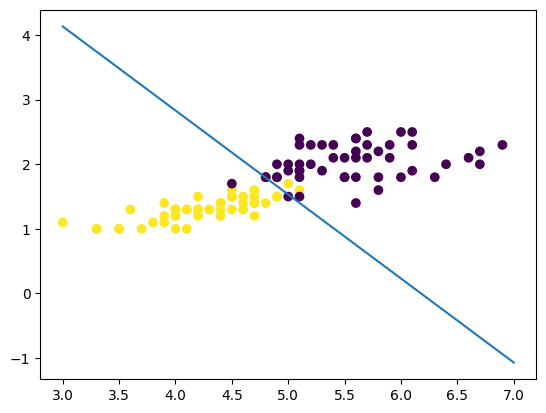

In [10]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

w2 = model.coef_[0,1]
w1 = model.coef_[0,0]
w0 = model.intercept_[0]

line=np.linspace(3,7)
plt.plot(line, -(w1*line+w0)/w2)
y_c = (y_iris=='versicolor').astype(int)
plt.scatter(iris2['petal_length'],iris2['petal_width'],c=y_c);

## 教師あり学習・回帰の例
以下では、アイリスデータセットを用いて花の特徴の1つ、`petal_length`、からもう1つの特徴、`petal_width`、を回帰する手続きを示しています。この時、`petal_length` は特徴量、`petal_width` は連続値のラベルとなっています。まず、`matplotlib` の散布図を用いて `petal_length` と `petal_width` の関係を可視化してみましょう。関係があるといえそうでしょうか。

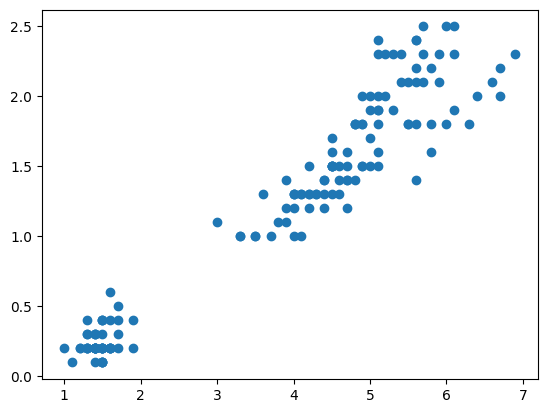

In [11]:
iris = pd.read_csv('iris.csv')
X=iris[['petal_length']].values
y=iris['petal_width'].values
plt.scatter(X,y);

次に、回帰を行うモデルの1つである**線形回帰** (**`LinearRegression`**) クラスをインポートしています。

[LinearRegressionクラス](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

`mean_squared_error()` は平均二乗誤差によりモデルの予測精度を評価するための関数です。

データセットを訓練データ (`X_train`, `y_train`) とテストデータ (`X_test`, `y_test`) に分割し、線形回帰クラスのインスタンスの `fit()` メソッドによりモデルを訓練データに適合させています。そして、`predict()` メソッドを用いてテストデータの `petal_length` の値から `petal_width` の値を予測し、`mean_squared_error()` 関数で実際の `petal_widthの値` (`y_test`) と比較して予測精度の評価を行なっています。

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

model=LinearRegression() # 線形回帰モデル
model.fit(X_train,y_train) # モデルを訓練データに適合
y_predicted=model.predict(X_test) # テストデータで予測
mean_squared_error(y_test,y_predicted) # 予測精度（平均二乗誤差）の評価

0.03974445760904277

以下では、線形回帰モデルにより学習された `petal_length` と `petal_width` の関係を表す回帰式を可視化しています。学習された回帰式が実際のデータに適合していることがわかります。

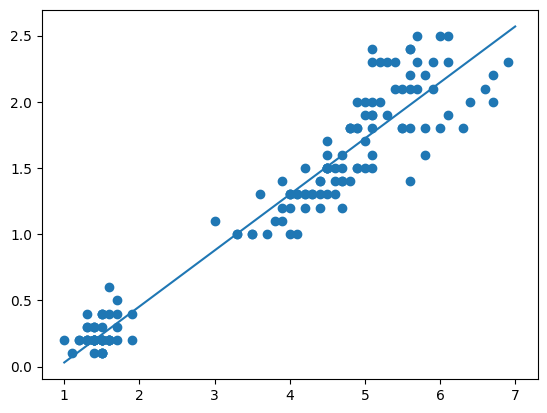

In [14]:
x_plot=np.linspace(1,7)
X_plot=x_plot[:,np.newaxis]
y_plot=model.predict(X_plot)
plt.scatter(X,y)
plt.plot(x_plot,y_plot);

## 教師なし学習・クラスタリングの例
以下では、アイリスデータセットを用いて花の2つの特徴量、`petal_lenghとpetal_width`、を元に花のデータをクラスタリングする手続きを示しています。ここでは**クラスタリング**を行うモデルの1つである **`KMeans`** クラスをインポートしています。

[KMeansクラス](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

特徴量データ (`X_irist`) を用意し、引数 `n_clusters` にハイパーパラメータとしてクラスタ数、ここでは `3`、を指定して `KMeans` クラスのインスタンスを作成しています。そして、`fit()` メソッドによりモデルをデータに適合させ、`predict()` メソッドを用いて各データが所属するクラスタの情報 (`y_km`) を取得しています。

学習された各花データのクラスタ情報を元のデータセットのデータフレームに列として追加し、クラスタごとに異なる色でデータセットを可視化しています。2つの特徴量、`petal_lengh` と `petal_width`、に基づき、3つのクラスタが得られていることがわかります。

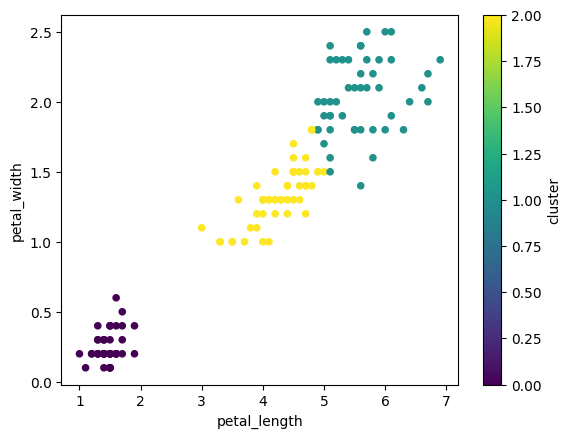

In [15]:
from sklearn.cluster import KMeans

iris = pd.read_csv('iris.csv')
X_iris=iris[['petal_length', 'petal_width']].values

model = KMeans(n_clusters=3) # k-meansモデル
model.fit(X_iris) # モデルをデータに適合
y_km=model.predict(X_iris) # クラスタを予測

iris['cluster']=y_km
iris.plot.scatter(x='petal_length', y='petal_width', c='cluster', colormap='viridis');

3つのクラスタと3つの花の種類の分布を2つの特徴量、`petal_lengh` と `petal_width`、の空間で比較してみると、クラスタと花の種類には対応があり、2つの特徴量から花の種類をクラスタとしてグループ分けできていることがわかります。以下では可視化に `seaborn` モジュールを用いています。

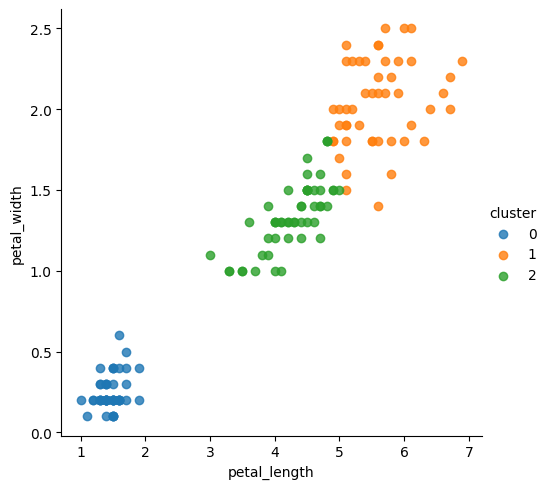

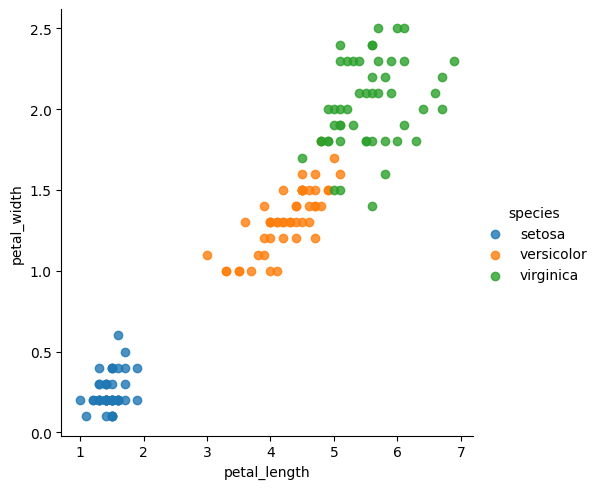

In [16]:
import seaborn as sns
sns.lmplot(x='petal_length',y='petal_width',hue='cluster',data=iris,fit_reg=False);
sns.lmplot(x='petal_length',y='petal_width',hue='species',data=iris,fit_reg=False);

このコードは、K-meansクラスタリングを使って、irisデータの花を3つのグループに自動分類し、その結果を散布図で可視化する処理。

※クラスタリング
データの中に潜む「似た者同士のグループ」を自動で見つけさせる技術。
機械学習の分類では、正解(ラベル)をあらかじめ教える「教師あり学習」が一般的だが、クラスタリングは正解を与えない「教師無し学習」に分類される。

①ライブラリの読み込み
from sklearn.cluster import KMeans
意味：
・scikit-learnのクラスタリングアルゴリズム
特徴：
・正解ラベル無しで似ているデータをグループ分け

②データ読み込み
iris=pd.read_csv("iris.csv")

③クラスタリングに使う特徴量
x_iris = iris[["petal_length","petal_width"]].values
DataFrame→NumPy配列
例
[[1.4,0.2],
 [1.3,0.2],
 [1.5,0.2]]

④K-meansモデル作成
model = KMeans(n_clusters = 3)
意味：3つのグループに分ける
理由：irisには3種類の花　setosa,versicolor,virginica

⑤モデル学習
model.fit(x_iris)
ここでやってること：
・データを読み込む→クラスタ中心を計算→最適な位置まで行進
K-meansアルゴリズム
1初期中心を決める
2各点を一番中心へ
3中心を再計算
4繰り返し

⑥クラスタ予測
y_km = model.predict(x_iris)
出力：
[0,0,0,0,0,1,1,1,2,2...]
意味：
データ①→cluster0
データ②→cluster0
データ③→cluster1
つまり、どのグループに属するか

⑦結果をDataFrameに追加
iris["cluster"] = y_km

新しい列
cluster
例
| petal_length | petal_width | cluster |
| ------------ | ----------- | ------- |
| 1.4          | 0.2         | 0       |
| 1.3          | 0.2         | 0       |
| 4.7          | 1.4         | 1       |
| 5.6          | 2.1         | 2       |

⑧散布図描画
iris.plot.scatter(
	x="petal_length",
	y="petal_width",
	c="cluster",
	colormap="viridis"
)
意味：
x軸　petal_length
y軸　petal_width
色　cluster
結果　3色のグラフ

colormap
viridis
色グラデーション
紫→青→緑→黄
可視化用の標準カラーマップ


自学追記
以下のコードは、K-meansクラスタリングの結果(cluster)と実際の花の種類(species)を可視化して比較する目的で書かれている。
使っているのはデータ可視化ライブラリseaborn

①seabornの読み込み
import seaborn as sns
意味：
・seaborn＝matplotlibをベースにした可視化ライブラリ
・統計グラフを少ないコードできれいに書ける

②lmplotとは何か
sns.lmplot()
正式名称：linear model plot
つまり、線形モデルの可視化
ただし今回は、
fit_reg=False
なので、回帰線は描画しない。
結果として散布図として使っている

③クラスタ結果の可視化
sns.lmplot(
	x="petal_length",
	y="petal_width",
	hue="cluster",
	data=iris
	fit_reg=False
);

hue="cluster"
・ここではcluster、つまりK-meansの分類結果

data=iris
※前回までの結果で
iris=pd.read_csv("iris.csv")
DataFrameの指定
つまり、
iris["petal_length"]
iris["petal_width"]
を使用

fit_reg = False
意味：
回帰線を書かない
Trueなら回帰線を描画


## 練習
アイリスデータセットの2つの特徴量、`sepal_length` と `sepal_width`、を元に、`KMeans` モデルを用いて花のデータをクラスタリングしてください。クラスタの数は任意に設定してください。

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

iris = pd.read_csv('iris.csv')
X_iris=iris[['sepal_length', 'sepal_width']].values

### your code here

## 教師なし学習・次元削減の例
以下では、アイリスデータセットを用いて花の4つの特徴量を元に花のデータを**次元削減**する手続きを示しています。ここでは次元削減を行うモデルの1つである **`PCA`** クラスをインポートしています。

[PCAクラス](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

特徴量データ (`X_irist`) を用意し、引数 `n_components` にハイパーパラメータとして削減後の次元数、ここでは `2`、を指定して `PCA` クラスのインスタンスを作成しています。そして、`fit()` メソッドによりモデルをデータに適合させ、**`transform()`** メソッドを用いて4つの特徴量を2次元に削減した特徴量データ (`X_2d`) を取得しています。

学習された各次元の値を元のデータセットのデータフレームに列として追加し、データセットを削減して得られた次元の空間において、データセットを花の種類ごとに異なる色で可視化しています。削減された次元の空間において、花の種類をグループ分けできていることがわかります。

In [17]:
from sklearn.decomposition import PCA

iris = pd.read_csv('iris.csv')
X_iris=iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

model = PCA(n_components=2) # PCAモデル
model.fit(X_iris) # モデルをデータに適合
X_2d=model.transform(X_iris) # 次元削減

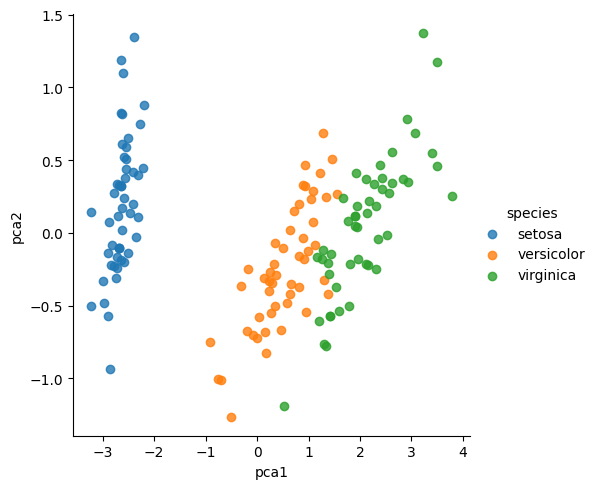

In [18]:
import seaborn as sns
iris['pca1']=X_2d[:,0]
iris['pca2']=X_2d[:,1]
sns.lmplot(x='pca1',y='pca2',hue='species',data=iris,fit_reg=False);

## 練習の解答例

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = pd.read_csv('iris.csv')
iris2=iris[(iris['species']=='versicolor')|(iris['species']=='virginica')]
X_iris=iris2[['petal_length','petal_width']].values
y_iris=iris2['species'].values

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=1, stratify=y_iris)

model=LogisticRegression(solver='lbfgs')
model.fit(X_train, y_train)
y_model=model.predict(X_test)
accuracy_score(y_test, y_model)

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

iris = pd.read_csv('iris.csv')
X_iris=iris[['sepal_length', 'sepal_width']].values

model = KMeans(n_clusters=3)
model.fit(X_iris)
y_km=model.predict(X_iris)

iris['cluster']=y_km
iris.plot.scatter(x='sepal_length', y='sepal_width', c='cluster', colormap='viridis');